##### 배경, 안피부 제거

W0000 00:00:1756979400.707780   40734 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1756979400.725084   40734 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


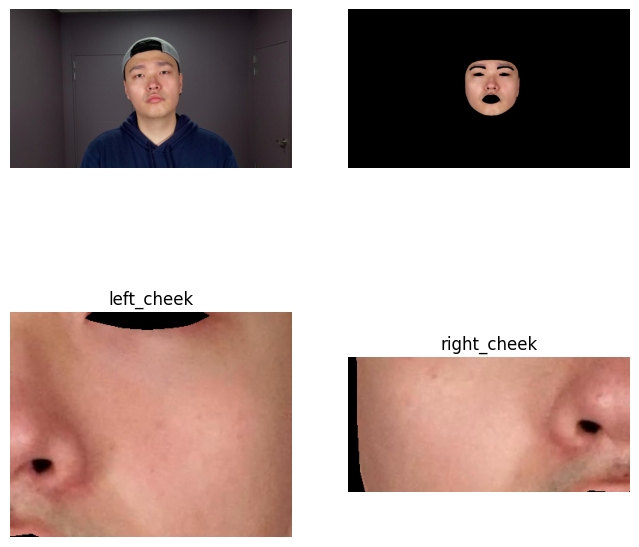

In [6]:
# landmark를 넘겨주자. 랜드마크를 쓰는 함수 2개를 사용하므로

import sys
sys.path.append('/home/work/hocheol_dir/workspace/preprocess2')
from remove_non_skin import remove_non_skin
sys.path.append('/home/work/hocheol_dir/workspace/preprocess2/pigment_data')
from crop_cv import crop_cheeks
import mediapipe as mp
import matplotlib.pyplot as plt
import cv2

face_mesh = mp.solutions.face_mesh.FaceMesh()

IMAGE_PATH = '/home/work/hocheol_dir/workspace/datasets2/_origin_data/114_data/data/0166_Phone_High_001.jpg'
img = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = face_mesh.process(img)
landmarks = results.multi_face_landmarks[0].landmark

img_rgb = remove_non_skin(img_rgb, landmarks)
left_cheek, right_cheek = crop_cheeks(img_rgb, landmarks)

fig, ax = plt.subplots(2, 2, figsize=(8,8))

ax[0][0].imshow(cv2.cvtColor(cv2.imread(IMAGE_PATH), cv2.COLOR_BGR2RGB))
ax[0][0].axis('off')

ax[0][1].imshow(img_rgb)
ax[0][1].axis('off')

ax[1][0].imshow(left_cheek)
ax[1][0].set_title('left_cheek')
ax[1][0].axis('off')

ax[1][1].imshow(right_cheek)
ax[1][1].set_title('right_cheek')
ax[1][1].axis('off')

plt.show()

In [1]:
import json
import os

image_root = '/home/work/hocheol_dir/workspace/datasets2/_origin_data'

with open('/home/work/hocheol_dir/workspace/datasets2/pigment_data/v0.3/pig_label_paths.json', 'r') as f:
    label_paths = json.load(f)
# label_paths

json_data = []

for e in label_paths:
    for step in ['train', 'val', 'test']:
        file_path = os.path.join(e, f"pig_{step}.json")
        with open(file_path, 'r') as f:
            json_data.extend(json.load(f))
len(json_data)

19090

In [3]:
left_paths = [data['left_path'] for data in json_data if data['left_path'] is not None]
right_paths = [data['right_path'] for data in json_data if data['right_path'] is not None]
len(left_paths), len(right_paths)

(18879, 19000)

In [13]:
import sys
sys.path.append('/home/work/hocheol_dir/workspace/preprocess2/pigment_data')
sys.path.append("/home/work/hocheol_dir/workspace/preprocess2")
import remove_non_skin
import crop_cv
import cv2
import os
import mediapipe as mp
import matplotlib.pyplot as plt
from tqdm import tqdm

target_root = '/home/work/hocheol_dir/workspace/datasets2/pigment_data/v0.3/v0.3_data'
face_mesh = mp.solutions.face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True)

for path in tqdm(left_paths):
    origin_path = os.path.join(image_root, path.replace('left_', ''))
    target_path = os.path.join(target_root, path)

    if os.path.exists(target_path):
        continue
    else:
        image = cv2.imread(origin_path)

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        results = face_mesh.process(image_rgb)
        landmarks = results.multi_face_landmarks[0].landmark

        masked_image = remove_non_skin.remove_non_skin(image_rgb, landmarks)
        left_cheek = crop_cv.crop_left_cheek(masked_image, landmarks)

        # fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        # ax[0].imshow(image)
        # ax[0].axis('off')
        # ax[1].imshow(left_cheek)
        # ax[1].axis('off')

        # plt.show()
        # plt.close()

        os.makedirs(os.path.dirname(target_path), exist_ok=True)
        cv2.imwrite(target_path, cv2.cvtColor(left_cheek, cv2.COLOR_RGB2BGR))

for path in tqdm(right_paths):
    origin_path = os.path.join(image_root, path.replace('right_', ''))
    target_path = os.path.join(target_root, path)
    if os.path.exists(target_path):
        continue
    else:
        image = cv2.imread(origin_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        results = face_mesh.process(image_rgb)
        landmarks = results.multi_face_landmarks[0].landmark

        masked_image = remove_non_skin.remove_non_skin(image_rgb, landmarks)
        right_cheek = crop_cv.crop_right_cheek(masked_image, landmarks)

        os.makedirs(os.path.dirname(target_path), exist_ok=True)
        cv2.imwrite(target_path, cv2.cvtColor(right_cheek, cv2.COLOR_RGB2BGR))

  0%|                                                                                                                                                                      | 0/18879 [00:00<?, ?it/s]W0000 00:00:1757293980.021532 1805685 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1757293980.042091 1805686 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
 92%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍            | 17448/19000 [12:02<04:18,  5.99it/s]Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
 92%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍         